# Main result: event probabilities and equity reopening values

This notebook presents the primary empirical estimate from **Closed for the Weekend**. All inputs below are frozen aggregate outputs from the research pipeline; no synthetic observations are used.

The coefficient is measured in basis points of peer-adjusted stock reopening movement per one-percentage-point favorable prediction-market revision.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pm_price_discovery.results import add_confidence_interval, load_result_table

ROOT = Path.cwd()
if not (ROOT / "data" / "derived").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "derived"
FIGURES = ROOT / "figures"

## Specification progression

Columns 1–6 hold the 1,173-observation sample fixed. The sequence moves from date fixed effects to stock fixed effects, then to event–firm-link fixed effects, and finally adds predetermined controls.

In [2]:
specs = load_result_table(
    DATA / "h1_specification_progression.csv",
    required_columns=["specification", "beta", "stock_date_se", "stock_date_pvalue"],
)

display_columns = [
    "column", "specification", "beta", "stock_date_se",
    "stock_date_pvalue", "observations",
]
specs[display_columns].round(3)

Spec.,Specification,Beta,Clustered SE,p-value,N
1,Date fixed effects,2.219,0.883,0.012,1173
2,Stock and date fixed effects,1.878,0.955,0.049,1173
3,Link and date fixed effects,2.637,1.244,0.034,1173
4,Add prior-session return,2.669,1.277,0.037,1173
5,Add final-30-minute return,2.787,1.271,0.028,1173
6,Primary specification,2.773,1.264,0.028,1173


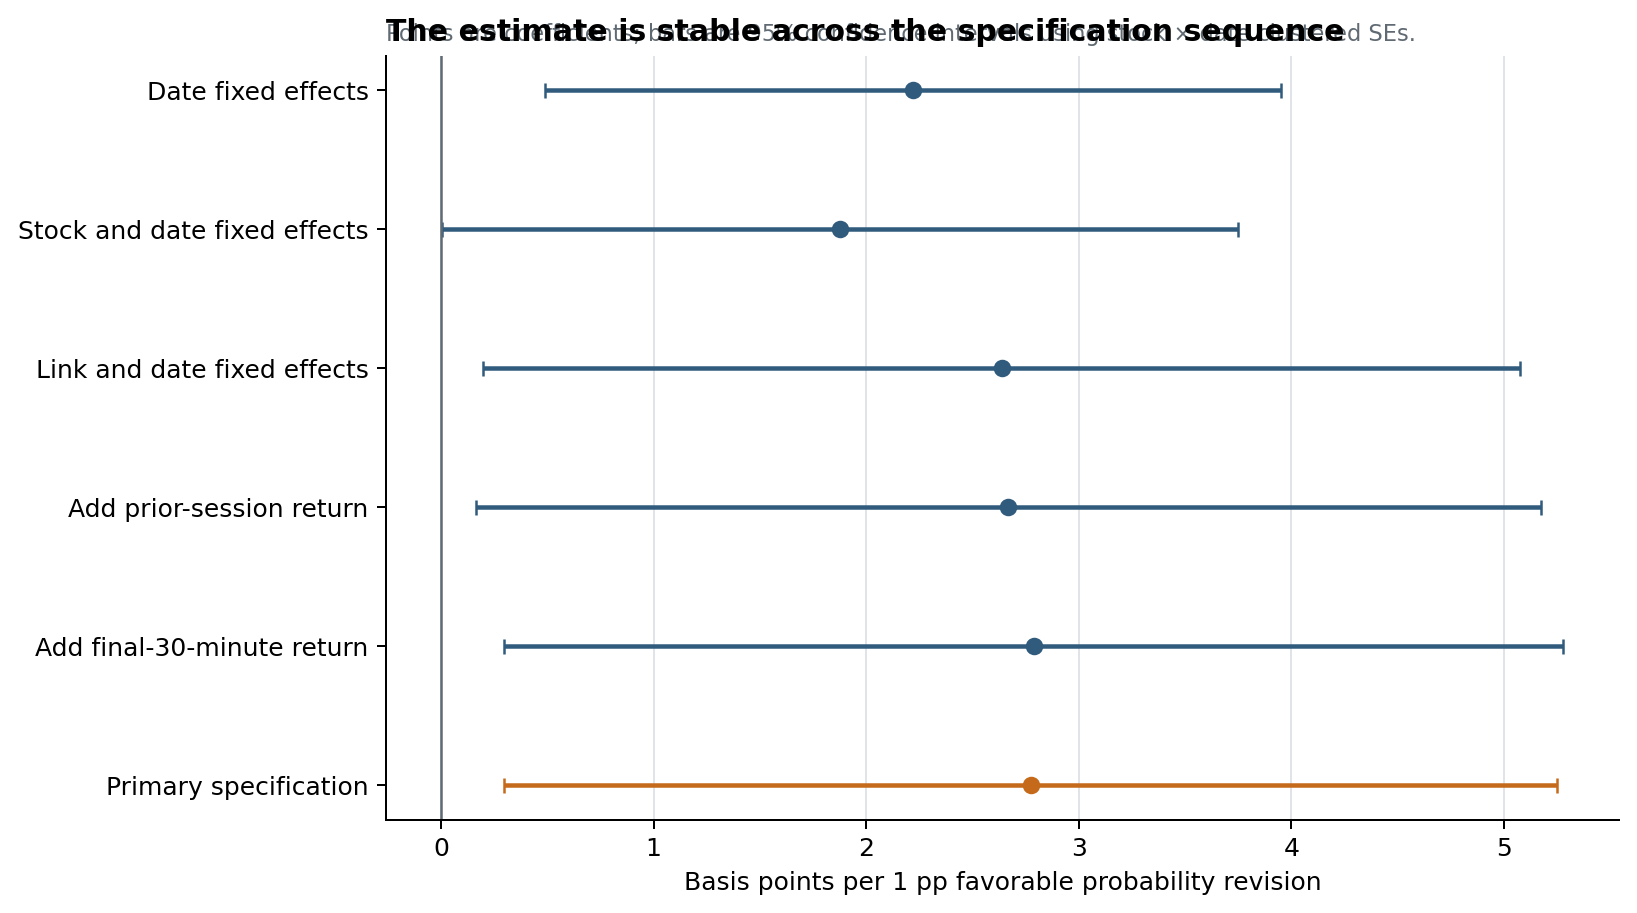

In [3]:
plot_data = add_confidence_interval(
    specs,
    estimate="beta",
    standard_error="stock_date_se",
)
y = np.arange(len(plot_data))
colors = ["#315b7d"] * (len(plot_data) - 1) + ["#c56a1a"]

fig, ax = plt.subplots(figsize=(9.2, 5.2))
for position, row, color in zip(y, plot_data.itertuples(), colors):
    ax.errorbar(
        row.beta,
        position,
        xerr=[[row.beta - row.ci_low], [row.ci_high - row.beta]],
        fmt="o", color=color, ecolor=color, capsize=3,
    )
ax.axvline(0, color="#606a73", linewidth=1)
ax.set_yticks(y, plot_data["specification"])
ax.invert_yaxis()
ax.set_xlabel("Basis points per 1 pp favorable probability revision")
ax.set_title("The estimate is stable across the specification sequence", loc="left", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#d9dee3", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURES / "h1_specification_progression.png", dpi=180, bbox_inches="tight")
plt.show()

## Primary estimate

The primary specification uses link and reopening-date fixed effects plus three pre-weekend controls. Standard errors below are two-way clustered.

In [4]:
primary = load_result_table(DATA / "h1_primary_result.csv")
row = primary.iloc[0]
ci = (
    row["estimate"] - 1.96 * row["stock_date_se"],
    row["estimate"] + 1.96 * row["stock_date_se"],
)

pd.DataFrame({
    "Estimate": [f"{row['estimate']:.3f}"],
    "95% CI": [f"[{ci[0]:.3f}, {ci[1]:.3f}]"],
    "Stock × date p": [f"{row['stock_date_pvalue']:.3f}"],
    "Market × date p": [f"{row['market_date_pvalue']:.3f}"],
    "Observations": [f"{int(row['observations']):,}"],
    "Links": [int(row["links"])],
})

Estimate,95% CI,Stock × date p,Market × date p,Observations,Links
2.773,"[0.298, 5.248]",0.028,0.008,"1,173",170


A ten-percentage-point favorable weekend revision corresponds to approximately **27.7 basis points** of favorable peer-adjusted reopening movement. Because link fixed effects absorb time-invariant differences across event–firm pairs, the estimate is identified from larger versus smaller revisions within the same reviewed relationship.

The closure establishes which market could move first; it does not imply that prediction-market trading itself causes the stock return.